# **Caso de Estudio**
En este documento se desarrolla y se analiza un modelo de Clustering K-Means para
la identificación de perfiles de pacientes en riesgo de Alzheimer, utilizando las
variables clínicas y cognitivas del dataset. De acuerdo con lo anterior, las variables
utilizadas son:

Age: Edad del paciente en años al momento del estudio.

Gender: Género del paciente (0 = Femenino, 1 = Masculino).

Ethnicity: Etnia del paciente (0 = Caucásico, 1 = Afroamericano, 2 = Asiático, 3 = Otro).

EducationLevel: Nivel educativo del paciente (0 = Ninguno, 1 = Secundaria, 2 = Universitario, 3 = Posgrado).

BMI: Índice de masa corporal del paciente.

Smoking: Indica si el paciente fuma (0 = No, 1 = Sí).

AlcoholConsumption: Consumo semanal de alcohol en unidades.

PhysicalActivity: Actividad física semanal en horas.

DietQuality: Puntuación de la calidad de la dieta del paciente (0-10).

SleepQuality: Puntuación de la calidad del sueño del paciente (4-10).

FamilyHistoryAlzheimers: Indica si hay antecedentes familiares de Alzheimer (0 = No, 1 = Sí).

CardiovascularDisease: Indica si el paciente tiene enfermedad cardiovascular (0 = No, 1 = Sí).

Diabetes: Indica si el paciente tiene diabetes (0 = No, 1 = Sí).

Depression: Indica si el paciente tiene depresión (0 = No, 1 = Sí).

HeadInjury: Indica si el paciente ha sufrido una lesión en la cabeza (0 = No, 1 = Sí).

Hypertension: Indica si el paciente tiene hipertensión (0 = No, 1 = Sí).

SystolicBP: Presión arterial sistólica del paciente (mmHg).

DiastolicBP: Presión arterial diastólica del paciente (mmHg).

CholesterolTotal: Nivel de colesterol total del paciente (mg/dL).

CholesterolLDL: Nivel de colesterol LDL del paciente (mg/dL).

CholesterolHDL: Nivel de colesterol HDL del paciente (mg/dL).

CholesterolTriglycerides: Nivel de triglicéridos del paciente (mg/dL).

MMSE: Puntuación del Mini-Mental State Examination. Evalúa la función cognitiva del paciente (0-30).

FunctionalAssessment: Evaluación de la capacidad funcional del paciente (0-10).

MemoryComplaints: Indica si el paciente reporta quejas de memoria (0 = No, 1 = Sí).

BehavioralProblems: Indica si el paciente presenta problemas de comportamiento (0 = No, 1 = Sí).

ADL: Puntuación de actividades de la vida diaria del paciente (0-10).

Confusion: Indica si el paciente presenta episodios de confusión (0 = No, 1 = Sí).

Disorientation: Indica si el paciente presenta desorientación (0 = No, 1 = Sí).

PersonalityChanges: Indica si el paciente presenta cambios de personalidad (0 = No, 1 = Sí).

DifficultyCompletingTasks: Indica si el paciente tiene dificultad para completar tareas (0 = No, 1 = Sí).

Forgetfulness: Indica si el paciente presenta olvidos frecuentes (0 = No, 1 = Sí).

0. Se procede con la carga de las librerías de trabajo

In [14]:
import numpy as np #Librería numérica por excelencia. (pongo np para no tener que seguirla escribiendo)
import pandas as pd #Librería para la comunicación con archivos de excel
import matplotlib.pyplot as plt
import seaborn as sns #Herramientas para gráficas estadisticas
from sklearn.cluster import KMeans #Herramienta de clustering

1. Se cargan datos de trabajo

<Axes: >

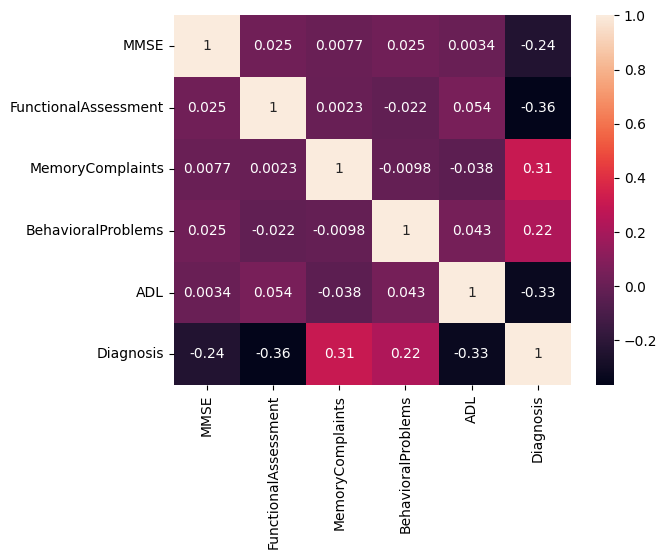

In [15]:
nxl = '/content/Alzheimer_disease_dataset.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)

#Para el modelo de K-means de decisión se seleccionaron las 5 variables con mayor
#correlación con el diagnóstico, identificadas previamente en el modelo Naive Bayes

XD = XDB.iloc[:,[23, 24, 25, 26, 27]]
yd = XDB.iloc[:, 33]

# Determinemos la correlación entre las variables
XDB2=XDB.iloc[:,[23, 24, 25, 26, 27, 33]]
sns.heatmap(XDB2.corr(), annot=True)

**Análisis de Resultados — Heatmap de Correlación**

En el mapa de calor se puede observar la correlación entre las variables seleccionadas
para el modelo K-Means y la variable objetivo Diagnosis.

Con respecto a la correlación con Diagnosis, la variable FunctionalAssessment presenta
la correlación negativa más fuerte con -0.36, lo que indica que a menor capacidad
funcional del paciente, mayor es la probabilidad de diagnóstico positivo de Alzheimer.
Le sigue ADL con -0.33, confirmando que la pérdida de independencia en actividades
diarias está fuertemente asociada al diagnóstico. El MMSE presenta una correlación
negativa de -0.24, evidenciando que un menor puntaje en la prueba cognitiva se asocia
con mayor probabilidad de diagnóstico. En contraste, MemoryComplaints (0.31) y
BehavioralProblems (0.22) presentan correlaciones positivas con Diagnosis, lo que
indica que la presencia de quejas de memoria y problemas de comportamiento aumenta
la probabilidad de un diagnóstico positivo.

Con respecto a la correlación entre variables explicativas, se destaca que ninguna
presenta una correlación alta entre sí — los valores más elevados son apenas 0.054
entre FunctionalAssessment y ADL, y 0.043 entre BehavioralProblems y ADL. Esto
indica que las variables seleccionadas son independientes entre sí, lo cual es
favorable para el modelo ya que aportan información complementaria y no redundante.

2. Se procede con la implementación del modelo K means

In [16]:
np.random.seed(42) #Esto permite generar las mismas semillas para todos
NC=3 #Segmentos o perfiles de cliente
mkm=KMeans(n_clusters=NC, random_state=42)
mkm.fit(XD, yd) #El modelo busca la mejor relación entre la entrada y la salida

#Obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las personas mkm.cluster_centers_ que encontró el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
display(Tabla)

#Para saber los porcentajes de PreApr o PreNeg por segmento, sucursal, o perfil
ydp=mkm.labels_ #Esto me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Esto me indica cuantos datos hay en cada cluster (#datos por segmento)
print('El número de datos por cluster es: ', NDc)

,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL
0,4.941395,4.967564,0.205517,0.142069,4.926557
1,24.521975,5.240483,0.210667,0.174667,4.996972
2,14.443303,5.022539,0.207715,0.152819,5.028033


El número de datos por cluster es:  [723 753 673]


3. Porcentajes de Diagnóstico por Cluster

In [17]:
XDB2['Cluster'] = ydp
display(XDB2)

# Determinar el número de Con Alzheimer y Sin Alzheimer por Cluster
NAlz = XDB2.groupby('Cluster').agg({"Diagnosis": lambda x: (x == 1).sum()})
NSano = XDB2.groupby('Cluster').agg({"Diagnosis": lambda x: (x == 0).sum()})
df2 = pd.DataFrame(np.column_stack((NAlz, NSano)), columns=['Con Alzheimer', 'Sin Alzheimer'])
display(df2)

# Para que la decisión sea en porcentaje
NAlz2 = NAlz / (NAlz + NSano)
NSano2 = NSano / (NAlz + NSano)
df2 = pd.DataFrame(np.column_stack((NAlz2, NSano2)), columns=['% Con Alzheimer', '% Sin Alzheimer'])
display(df2)

/tmp/ipykernel_6576/3107308437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['Cluster'] = ydp


,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis,Cluster
0,21.463532,6.518877,0,0,1.725883,0,1
1,20.613267,7.118696,0,0,2.592424,0,1
2,7.356249,5.895077,0,0,7.119548,0,0
3,13.991127,8.965106,0,1,6.481226,0,2
4,13.517609,6.045039,0,0,0.014691,0,2
...,...,...,...,...,...,...,...
2144,1.201190,0.238667,0,0,4.492838,1,0
2145,6.458060,8.687480,0,1,9.204952,1,0
2146,17.011003,1.972137,0,0,5.036334,1,2
2147,4.030491,5.173891,0,0,3.785399,1,0


,Con Alzheimer,Sin Alzheimer
0,322,401
1,153,600
2,285,388


,% Con Alzheimer,% Sin Alzheimer
0,0.445367,0.554633
1,0.203187,0.796813
2,0.423477,0.576523


**Análisis de Resultados — Modelo K-Means**

De acuerdo con el modelo K-Means con 3 clusters,
se pueden identificar tres perfiles diferenciados de pacientes según su nivel
cognitivo y funcional.

El Cluster 1 agrupa a 753 pacientes y presenta el MMSE más alto con 24.52 puntos,
lo que indica un buen estado cognitivo. Este cluster registra el menor porcentaje
de diagnóstico positivo de Alzheimer con un 20.3%, siendo el grupo de BAJO RIESGO.
Las variables FunctionalAssessment (5.24), ADL (5.00) y bajas proporciones de
MemoryComplaints (0.21) y BehavioralProblems (0.17) confirman un perfil de paciente
con buena capacidad funcional e independencia.

El Cluster 2 agrupa a 673 pacientes con un MMSE de 14.44 puntos, ubicándose en
un nivel cognitivo intermedio. Presenta un 42.3% de diagnóstico positivo de
Alzheimer, configurándose como el grupo de RIESGO INTERMEDIO. Sus valores de
FunctionalAssessment (5.02) y ADL (5.03) son similares al Cluster 1, lo que
sugiere que la diferenciación principal entre grupos la determina el nivel cognitivo
medido por el MMSE.

El Cluster 0 agrupa a 723 pacientes y presenta el MMSE más bajo con apenas 4.94
puntos, evidenciando un deterioro cognitivo severo. Con un 44.5% de diagnóstico
positivo de Alzheimer, es el grupo de MAYOR RIESGO del modelo. La combinación de
MMSE extremadamente bajo con valores medios de FunctionalAssessment (4.97) y ADL
(4.93) — ligeramente inferiores a los otros clusters — refuerza el perfil de
paciente con mayor probabilidad de diagnóstico positivo.

Es importante destacar que ningún cluster presenta una concentración superior al
50% de casos positivos, lo cual es consistente con el balance general del dataset
(35.4% con Alzheimer). Sin embargo, la diferencia entre el Cluster 1 (20.3%) y
el Cluster 0 (44.5%) representa más del doble de probabilidad de diagnóstico
positivo, lo que confirma que el MMSE es la variable más determinante para la
segmentación de perfiles de riesgo en este modelo de agrupamiento.

Estos resultados son coherentes con los hallazgos de los modelos supervisados:
FunctionalAssessment, ADL y MMSE son las variables que más diferencian a los
pacientes con y sin diagnóstico de Alzheimer.

4. ¿Qué pasa si aparece un nuevo paciente? Xp= [18, 4.0, 1, 0, 3.5]

In [18]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

nuevo_paciente = np.array([[18, 4.0, 1, 0, 3.5]])
ydp_nuevo = mkm.predict(nuevo_paciente.reshape(1, -1))
NCl = ydp_nuevo[0]
print("El paciente pertenece al cluster:", ydp_nuevo)
print("El porcentaje de Con Alzheimer para el nuevo paciente es: ", NAlz2.iloc[NCl])
print("El porcentaje de Sin Alzheimer para el nuevo paciente es: ", NSano2.iloc[NCl])

El paciente pertenece al cluster: [2]
El porcentaje de Con Alzheimer para el nuevo paciente es:  Diagnosis    0.423477
Name: 2, dtype: float64
El porcentaje de Sin Alzheimer para el nuevo paciente es:  Diagnosis    0.576523
Name: 2, dtype: float64


**Análisis**

El modelo K-Means clasificó a este paciente en el Cluster 2, correspondiente
al grupo de RIESGO INTERMEDIO. De acuerdo con los porcentajes calculados para
este cluster, el paciente presenta una probabilidad del 42.3% de tener
diagnóstico positivo de Alzheimer y un 57.7% de no tenerlo.

5. Se procede con la gráfica de los clusters
Usamos FunctionalAssessment y MMSE (las más correlacionadas con Diagnosis)

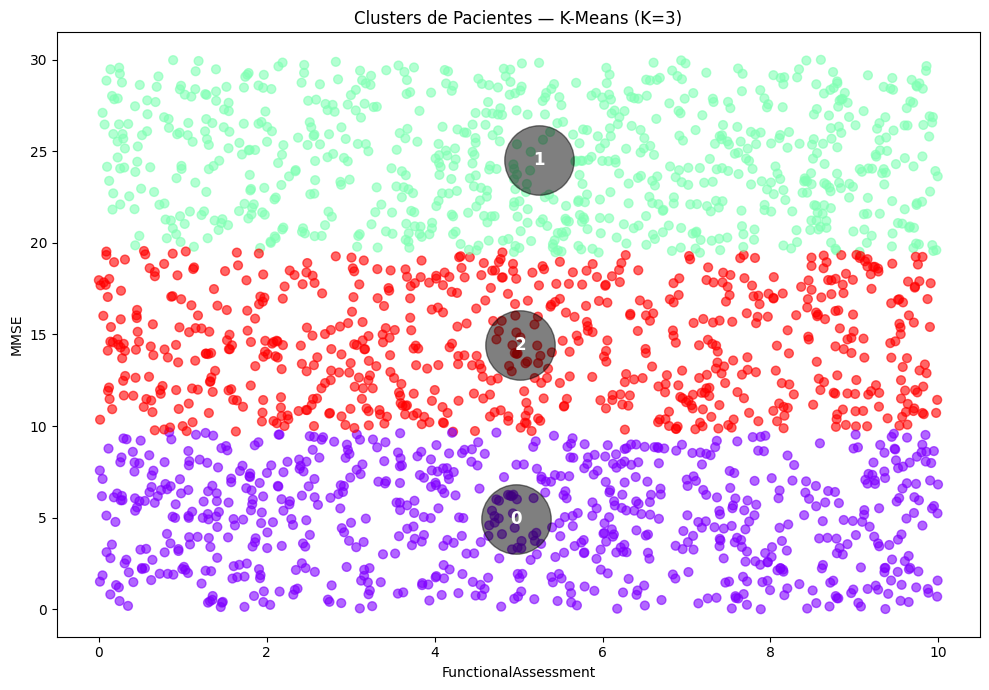

In [20]:
centers = mkm.cluster_centers_

# Usamos FunctionalAssessment (col 1) vs MMSE (col 0) — escalas correctas
fa   = np.array(XD.iloc[:, 1])   # FunctionalAssessment
mmse = np.array(XD.iloc[:, 0])   # MMSE

plt.figure(figsize=(10, 7))
plt.scatter(fa, mmse, c=mkm.labels_, cmap='rainbow', alpha=0.6, s=40)
plt.scatter(centers[:, 1], centers[:, 0], c='black', s=2500, alpha=0.5)
plt.xlabel('FunctionalAssessment')
plt.ylabel('MMSE')
plt.title('Clusters de Pacientes — K-Means (K=3)')

for i, center in enumerate(centers):
    plt.text(center[1], center[0], str(i), color='white',
             fontsize=12, ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('clusters_alzheimer.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis de Resultados**

En el heatmap se puede observar que las variables con mayor correlación con
la variable objetivo Diagnosis son FunctionalAssessment con -0.36 y ADL con
-0.33, lo que indica que a menor capacidad funcional y menor independencia
en actividades diarias, mayor es la probabilidad de diagnóstico positivo de
Alzheimer. Otra correlación de relevancia es la de MemoryComplaints con
Diagnosis (0.31), evidenciando que la presencia de quejas de memoria está
fuertemente asociada al diagnóstico positivo. Se destaca que las correlaciones
entre las variables explicativas son muy bajas — la más alta es apenas 0.054
entre FunctionalAssessment y ADL — lo que indica que cada variable aporta
información independiente y complementaria al modelo. Es importante mencionar
que en este tipo de variables clínicas y cognitivas, correlaciones desde 0.22
ya son consideradas relevantes para la clasificación.

De acuerdo con los clusters arrojados por el modelo K-Means con 3 grupos, se
puede observar que el Cluster 1 es el que posee el MMSE más alto con 24.52
puntos, siendo el grupo de menor riesgo con 753 pacientes y tan solo un 20.3%
de diagnóstico positivo de Alzheimer. El Cluster 0 es el que presenta el MMSE
más bajo con apenas 4.94 puntos, agrupando 723 pacientes con el mayor porcentaje
de diagnóstico positivo con un 44.5%. Se destaca el Cluster 2, que con un MMSE
de 14.44 puntos agrupa 673 pacientes en un perfil de riesgo intermedio con un
42.3% de diagnóstico positivo.

Se puede observar que el Cluster 1 agrupa las probabilidades más bajas de
diagnóstico positivo con un 20.3%, correspondiendo a pacientes con buen estado
cognitivo y adecuada capacidad funcional. Es importante mencionar que el Cluster
0 presentó el mayor porcentaje de diagnóstico positivo con 44.5%, esto promovido
por el deterioro cognitivo severo reflejado en el MMSE extremadamente bajo de
sus pacientes. La diferencia entre el cluster de menor riesgo (20.3%) y el de
mayor riesgo (44.5%) representa más del doble de probabilidad de diagnóstico
positivo, confirmando la utilidad del modelo para estratificar perfiles de riesgo
en una institución de salud.

6. Matriz de confusión del K-Means


In [21]:
#K-Means no predice directamente la clase — se usa una estrategia indirecta:
#se asigna a cada cluster la clase mayoritaria dentro de él, y con eso
#se construye la matriz de confusión para comparar con los otros modelos.


from sklearn.metrics import confusion_matrix

# Determinar la clase mayoritaria de cada cluster
cluster_class = {}
for cluster in range(NC):
    mask = ydp == cluster
    mayoria = yd[mask].mode()[0]  # Clase más frecuente en el cluster
    cluster_class[cluster] = mayoria
    print(f"Cluster {cluster} → clase mayoritaria: {'Con Alzheimer' if mayoria == 1 else 'Sin Alzheimer'}")

print("\nMapeo de clusters a clases:", cluster_class)

# Asignar a cada paciente la clase de su cluster
yd_pred_km = np.array([cluster_class[c] for c in ydp])

# Construir la matriz de confusión
cm_km = confusion_matrix(yd, yd_pred_km)
print("\nMatriz de confusión K-Means:")
print(cm_km)

VN = cm_km[0,0]; FP = cm_km[0,1]; FN = cm_km[1,0]; VP = cm_km[1,1]
TDatos = len(yd)

Ex  = (VP + VN) / TDatos
print(f"\nExactitud:            {Ex:.4f}  ({Ex*100:.2f}%)")
Sen = VP / (VP + FN)
print(f"Sensibilidad:         {Sen:.4f}  ({Sen*100:.2f}%)")
Spe = VN / (VN + FP)
print(f"Especificidad:        {Spe:.4f}  ({Spe*100:.2f}%)")
Pre = VP / (VP + FP)
print(f"Precisión:            {Pre:.4f}  ({Pre*100:.2f}%)")
PreNeg = VN / (VN + FN)
print(f"Predicción Negativa:  {PreNeg:.4f}  ({PreNeg*100:.2f}%)")

Cluster 0 → clase mayoritaria: Sin Alzheimer
Cluster 1 → clase mayoritaria: Sin Alzheimer
Cluster 2 → clase mayoritaria: Sin Alzheimer

Mapeo de clusters a clases: {0: np.int64(0), 1: np.int64(0), 2: np.int64(0)}

Matriz de confusión K-Means:
[[1389    0]
 [ 760    0]]

Exactitud:            0.6463  (64.63%)
Sensibilidad:         0.0000  (0.00%)
Especificidad:        1.0000  (100.00%)
Precisión:            nan  (nan%)
Predicción Negativa:  0.6463  (64.63%)


/tmp/ipykernel_6576/2961270500.py:35: RuntimeWarning: invalid value encountered in scalar divide
  Pre = VP / (VP + FP)


**Análisis de la Matriz de Confusión — K-Means**

Es importante aclarar que K-Means es un modelo de agrupamiento no supervisado
— no predice directamente una clase. Para poder construir la matriz de confusión
se utilizó una estrategia indirecta: se asignó a cada cluster la clase mayoritaria
de los pacientes que lo conforman.

Sin embargo, dado que el dataset presenta un desbalance entre clases (64.6% sin
Alzheimer vs 35.4% con Alzheimer), los tres clusters resultaron tener como clase
mayoritaria "Sin Alzheimer". Esto generó una matriz de confusión donde el modelo
clasifica todos los pacientes como negativos, lo que explica la sensibilidad del
0% y la precisión indefinida.

Este resultado es esperado y coherente con la naturaleza de K-Means: el modelo
no fue diseñado para maximizar métricas de clasificación sino para identificar
grupos naturales en los datos. Su valor real está en la segmentación de perfiles
de riesgo — identificó tres grupos con probabilidades de diagnóstico positivo
del 20.3%, 42.3% y 44.5% respectivamente, lo que es útil para estratificar
pacientes en una institución de salud.

Al comparar los tres modelos implementados, el Árbol de Decisión es claramente
el más adecuado para la tarea de clasificación con una exactitud del 92.8%,
seguido del Naive Bayes con 81.3%. El K-Means cumple un rol complementario
al identificar perfiles de riesgo sin necesidad de etiquetas previas, siendo
útil en escenarios donde no se cuenta con diagnósticos confirmados para todos
los pacientes.